In [6]:
import sys
sys.path.append('../src')

In [7]:
import os
print(os.getcwd())

C:\Users\Lenovo\Documents\Machine learning\Projects\Real_state_intelligence_system\notebooks


In [8]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

In [9]:
dataset = pd.read_csv("AmesHousing.csv")

In [10]:
from feature_engineering import add_engineered_features

dataset = add_engineered_features(dataset)

## Encoding (Conceptual , no coding)

In [11]:
ordinal_cols = [ 'Lot shape' ,'Land Slope','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
               'Heating QC','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond',
                'Pool QC','Paved Drive']

nominal_low = [ 'MS Zoning' ,'Street' , 'Alley', 'Land Contour','Utilities','Lot Config','Condition 1','Condition 2','Bldg Type','House Style','Roof Style'
              ,'Roof Matl','Mas Vnr Type','Foundation','Heating','Garage Type','Misc Feature','Sale Type','Sale Condition',
              'Fence','Electrical']

nominal_high = [ 'Neighborhood','Exterior 1st','Exterior 2nd']

Binary = ['Central Air', 'Has_Basement', 'Is_Remodeled' , 'Garage Exists']

num_cols = [ 'House Age','Year since Remodel','Total Living Area','Total Finished Area','Total Bathrooms','Garage Age',
    'Quality_size_score','Non_Bedroom_Rooms']    # True Quantities --> where distance and magnitude matters 

## TRAIN / VALIDATION STRATEGY & LEAKAGE CONTROL

### As we see Sale Price ( target variable ) is highly skewed (Right skewed) so transformation needed

In [12]:
dataset['SalePrice'].skew()

1.7435000757376466

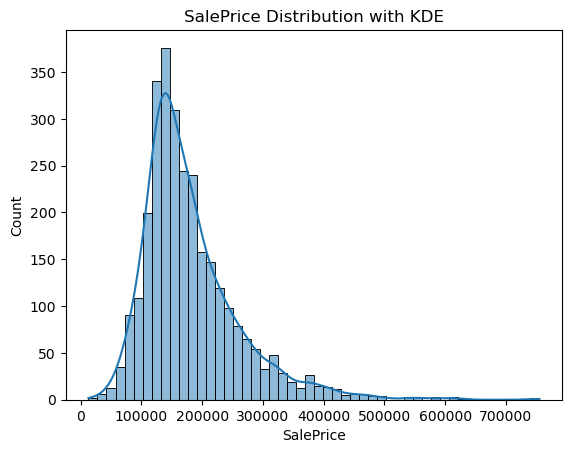

In [13]:
sns.histplot(dataset['SalePrice'], bins=50, kde=True)
plt.title('SalePrice Distribution with KDE')
plt.show()

### Applying log1p transformation on SalePrice (target feature)

In [14]:
dataset['SalePrice_log'] = np.log1p(dataset['SalePrice'])

In [15]:
dataset['SalePrice_log'].skew()      # SomeWhat Left skewed but okay 

-0.014772659537224368

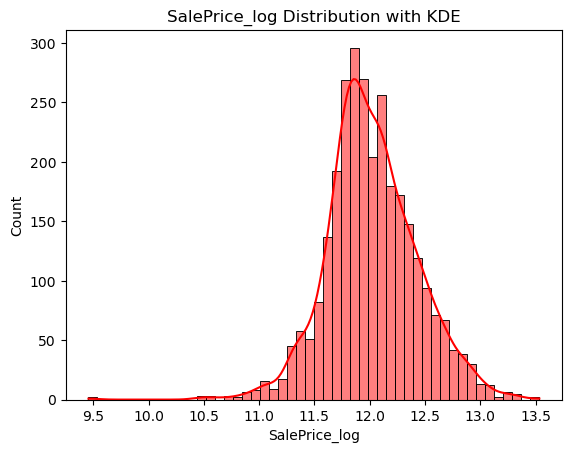

In [16]:
sns.histplot(dataset['SalePrice_log'], bins=50, kde=True , color = 'red')
plt.title('SalePrice_log Distribution with KDE')
plt.show()

## splitting 

In [17]:
y = dataset['SalePrice_log']
X = dataset.drop(columns=['SalePrice','SalePrice_log'])

# Encoding practically (Coding)

### As we know we can't use the same order for all ordinals cols as some have same order while some has diff 

In [18]:
Qual_bsd_fea = ['Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Heating QC','Kitchen Qual','Fireplace Qu','Garage Qu','Garage Cond','Pool QC']
qual_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

Bsmt_expos = ['Bsmt Exposure']
bsmt_exposure_order = ['None', 'No', 'Mn', 'Av', 'Gd']

BsmtFinish = ['BsmtFin Type 1','BsmtFin Type 2']
bsmt_finish_order = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

GarageFinsh = ['Garage Finish'];
garage_finish_order = ['None', 'Unf', 'RFn', 'Fin']

Functional_col = ['Functional']
functional_order = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']

pvd_drive = ['Paved Drive']
paved_drive_order = ['N', 'P', 'Y']

land_slope_col = ['Land Slope']
land_slope_order = ['Sev', 'Mod', 'Gtl']

lot_shape_col = ['Lot Shape']
lot_shape_order = ['IR3', 'IR2', 'IR1', 'Reg']

In [19]:
ordinal_columns = ( Qual_bsd_fea + Bsmt_expos + BsmtFinish + GarageFinsh + Functional_col + pvd_drive + land_slope_col
    + lot_shape_col )

# Since Ordinal Encoder doesn't know meaning , It only matches column position with order position ( so that's why I flatten all list into single lsit ) 
#  and why this [qual_order] * len(Qual_bsd_fea) to correspond the feature to their order 
ordinal_orders = (
    [qual_order] * len(Qual_bsd_fea) +
    [bsmt_exposure_order] * len(Bsmt_expos) +
    [bsmt_finish_order] * len(BsmtFinish) +
    [garage_finish_order] * len(GarageFinsh) +
    [functional_order] * len(Functional_col) +
    [paved_drive_order] * len(pvd_drive) +
    [land_slope_order] * len(land_slope_col) +
    [lot_shape_order] * len(lot_shape_col)
)

In [20]:
len(ordinal_columns) == len(ordinal_orders)

True